<a href="https://colab.research.google.com/github/MarlonSC14/Hyperparameter-search-in-XGBoost/blob/colab_code/hyperparameter_search_in_XGB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The objective of this notebook is to study different kinds of hyperparameter search included in the sklearn library for an XGBoost classification problem.

# Setup

Installing the specific versions of the libraries that we will need throughout the code, importing them and cloning/importing a repository with auxiliary scripts.

**Important: If you are running the code in Google Colab, make sure to switch the runtime type to T4 GPU.**

In [1]:
!pip install mplhep
!pip install matplotlib==3.1.3
!pip install xgboost==3.3.0

  Using cached matplotlib-3.1.3.tar.gz (40.9 MB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [2]:
import xgboost as xgb
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, recall_score, precision_score, auc, precision_recall_curve
from hyperopt import fmin, hp, tpe, STATUS_OK
import pprint
import seaborn as sns
import os
import sys

In [3]:
!git clone https://github.com/MarlonSC14/scripts # Importing the contents from this github repository to use some auxiliary (important) python scripts with functions
sys.path.append('/content/scripts') # Adding the cloned folder to the system path

Cloning into 'scripts'...
remote: Enumerating objects: 337, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 337 (delta 0), reused 0 (delta 0), pack-reused 332 (from 1)
Receiving objects: 100% (337/337), 134.03 KiB | 707.00 KiB/s, done.
Resolving deltas: 100% (207/207), done.


In [4]:
# Importing functions from the auxiliary scripts imported from git
import plot_tools_and_functions_xgb as ptf

# Importing data

For this github repository, only a zip file with a sample of the data is displayed. In order to use it, you must unzip it and download it.

In [5]:
# Mounting to your google account
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Path where the data is
path_ = 'the path to the data'

In [7]:
# You will need to decompress the zip sample data and download it to use it.
# Originally this DataFrames had 4002800 entries (background) and 40028 entries (signal). Since this is a demonstrative public exercise, a sample of 5% was taken for background and 15% for signal.
LR=pd.read_pickle(path_+'sample_XGB_left_right_4040_all.pkl') # Importing background data
S= pd.read_pickle(path_+'sample_XGB_signal_4040_all.pkl') # Importing signal data

# Working with data

We get information from the datasets and we start to get familiar with the data.

In [ ]:
LR.info() #Getting information from the background DataFrame

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 200140 entries, (np.uint64(319337), np.uint64(1120), np.uint64(977864946), np.int64(6)) to (np.uint64(319579), np.uint64(2453), np.uint64(3823074208), np.int64(1))
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DiMuMass     200140 non-null  float32
 1   BMass        200140 non-null  float32
 2   cosThetaKMu  200140 non-null  float32
 3   Bpt          200140 non-null  float32
 4   kpt          200140 non-null  float32
 5   mu1_pt       200140 non-null  float32
 6   mu2_pt       200140 non-null  float32
 7   PDL          200140 non-null  float32
 8   prob         200140 non-null  float32
 9   cosA         200140 non-null  float32
 10  signLxy      200140 non-null  float32
dtypes: float32(11)
memory usage: 51.3 MB


In [ ]:
S.info(max_cols=120) #Getting information from the signal DataFrame

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 6004 entries, (np.float64(2.0), np.uint64(1305), np.uint64(1905317), np.int64(0)) to (np.float64(1.0), np.uint64(53216), np.uint64(5321506), np.int64(0))
Data columns (total 101 columns):
 #    Column                  Non-Null Count  Dtype  
---   ------                  --------------  -----  
 0    Bpt                     6004 non-null   float32
 1    fit_eta                 6004 non-null   float32
 2    fit_phi                 6004 non-null   float32
 3    BMass                   6004 non-null   float32
 4    PDL                     6004 non-null   float32
 5    ePDL                    6003 non-null   float32
 6    cosThetaKMu             6004 non-null   float32
 7    prob                    6004 non-null   float32
 8    lxy_proj_significance   6003 non-null   float32
 9    signLxy                 6003 non-null   float32
 10   cosA                    6004 non-null   float32
 11   fit_cos2D               6004 non-null   float32
 12   

Plotting a histogram of the "BMass" feature of the DataFrames. This feature is the key to identify signal and background.

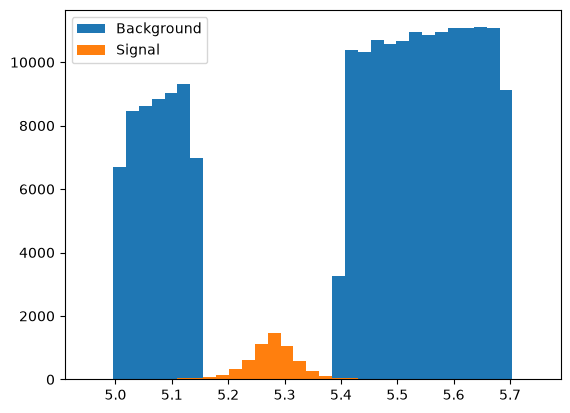

In [ ]:
opts = dict(range=[4.95,5.75], bins=35, density=False) # Personalizing the histogram
plt.hist(LR.BMass, label='Background', **opts) # Creating a histogram for the BMass feature in the background dataset
plt.hist(S.BMass, label='Signal', **opts) # Creating a histogram for the BMass feature in the signal dataset
plt.legend()
plt.show() # Plotting both histograms in the same graph

In [8]:
cols=['Bpt', 'kpt', 'PDL', 'prob', 'cosA', 'signLxy'] # Selecting the columns to work with in this exercise

In [9]:
# We mix both DataFrames in order to create our XGB model
LR['label'] = 0
S['label'] = 1 # Labeling the signal and Background DataFrames
total = pd.merge(S[cols+['label']],LR[cols+['label']],how='outer') # Merging signal and background DataFrames
train, test = train_test_split(total, test_size=0.3, random_state=1) # Using the train_test_split method from sklearn to get a training and a testing DataFrame (in this case we split 70% train and 30% test)
sample_size = total.shape[0] # Obtaining the size of the merged dataframe

In [10]:
# Defining the evaluation set to train the data in the following sections
evaluation= [(train[cols], train['label']),(test[cols],test['label'])]

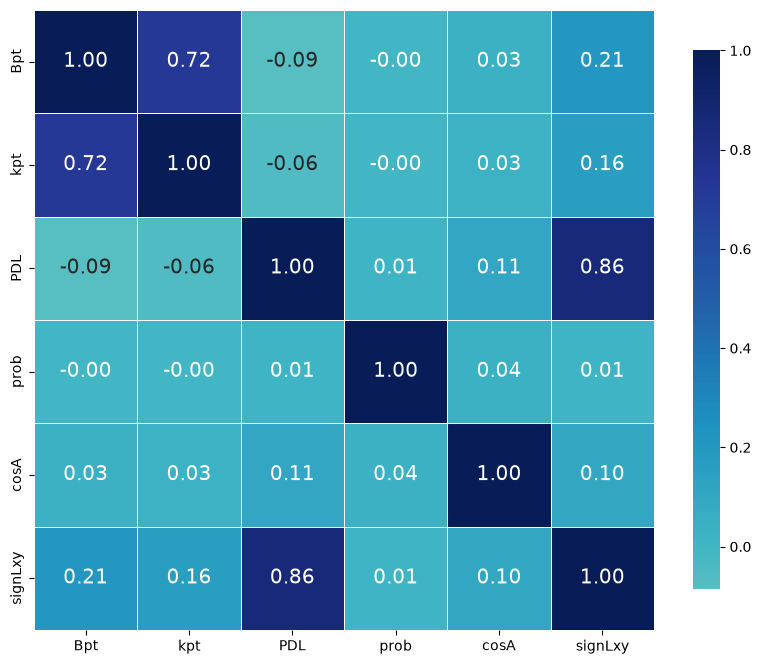

In [11]:
# This is a functon that plots a heatmap of the correlations between features (columns) in our dataset.
# Depending on how correlated these features are, we might decide to discard some of them. In this case we conserve all columns (6).
ptf.correlation_heatmap(S[cols])

# **Recall metric**

### First XGB recall model

In [ ]:
# In case that we have an already trained model saved, we can load it uncommenting the following code.
# loaded_model = xgb.XGBClassifier() # Defining a variable as an XGBoost classifier
# loaded_model.load_model(path_+"optimized_recall_model_per_hparams.json") # Loading the model from the path where it is saved

In [11]:
# Creating an XGBoost model
model_recall = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain' # Dictates the metric to calculate feature importance
                      )

In [12]:
# Defining some parameters from our model. It is mandatory to define these parameters this way and not into the definition of the classifier since we are using a custom metric
# Using the recall metric defined previously
#early_stopping_rounds is a parameter that stops model training when the performance on the validation dataset stops improving
model_recall.set_params(custom_metric = ptf.recall_eval, early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function recall_eval at 0x7d390c594360>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, ...)

In [13]:
# Training the model with our data using the recall metric
model_recall.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function recall_eval at 0x7d390c594360>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, ...)

{'Bpt': 0.021353496238589287,
 'PDL': 0.020199788734316826,
 'cosA': 0.6167211532592773,
 'kpt': 0.18459674715995789,
 'prob': 0.037120237946510315,
 'signLxy': 0.12000858038663864}


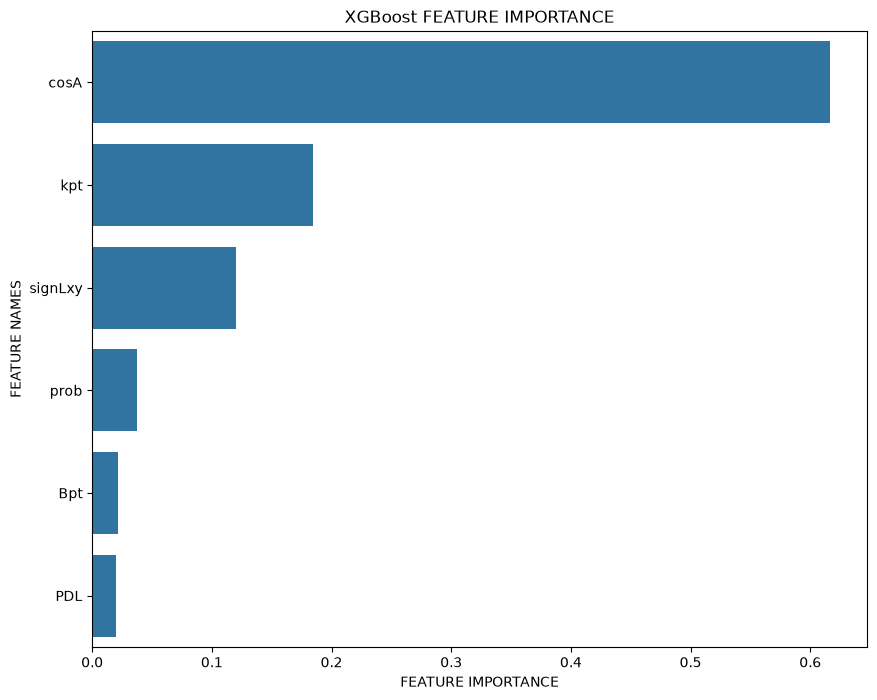

In [14]:
# This is a functin that plots a histogram of the importance of the features (columns) that we are working with. In this case, we specified to calculate the importance with the "gain" metric in this model.
ptf.plot_feature_importance(model_recall.feature_importances_, train[cols].columns, "XGBoost")

### Evaluation

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [20:07:36] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Own ks test

	0.8560873777461462
	0.05659666627921


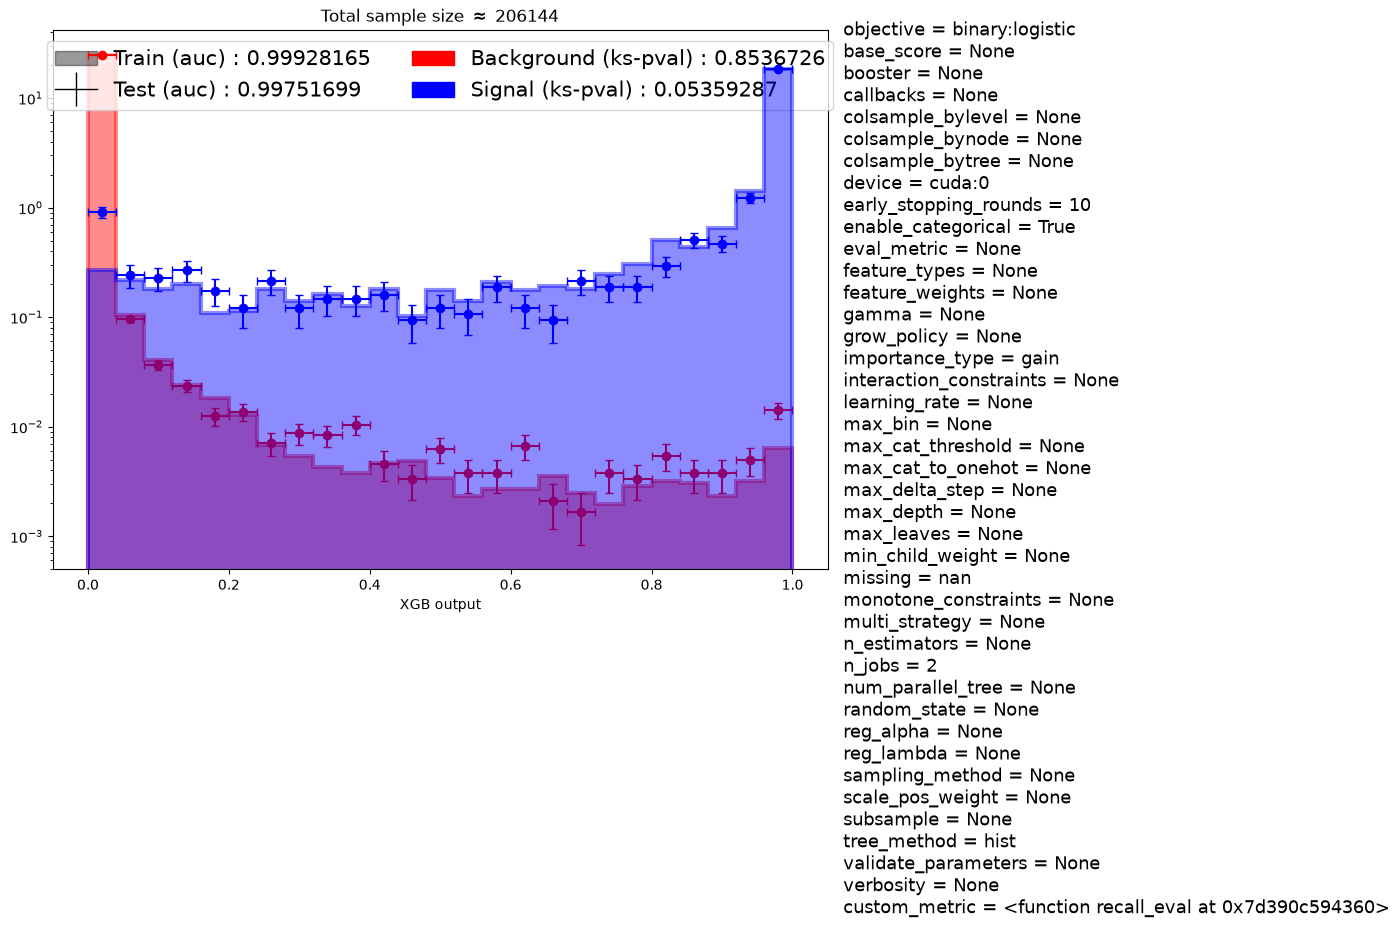

In [15]:
# The plot_classifier_distributions function plots histograms for the train and test DataFrames for signal and background. Then returns the pvalues for each set using ks test
fig, ax = ptf.plot_classifier_distributions(model_recall, test=test, train=train, cols=cols, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()

Text(0.5, 1.0, 'precision-recall curve for recall model')

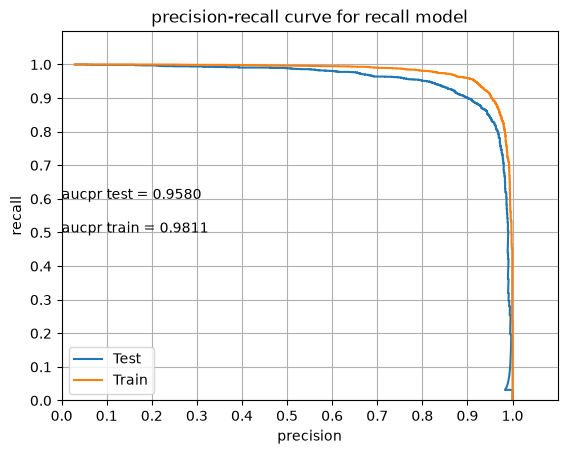

In [16]:
# Plotting the precision-recall curve for our model. We ensure our model is not overtrained since the test curve (blue) is beneath the train curve (orange).
# We additionally get the aucpr (area under the precision-recall curve) values. A perfect model would give an aucpr value of 1.
fig, ax = ptf.plot_precision_recall_curve(model_recall, train, test, cols)
plt.title('precision-recall curve for recall model')

In [17]:
model_recall.save_model(path_+"recall_model.json") #Saving our model into a destination and with a name of our choice

# **Precision metric**

### First XGB precision model

In [18]:
# Creating an XGBoost model
model_precision = xgb.XGBClassifier(objective='binary:logistic',
                         tree_method = 'hist',
                         device="cuda:0",
                         n_jobs=os.cpu_count(),
                         importance_type = 'gain'
                      )

In [19]:
# Defining parameters for our model.
model_precision.set_params(custom_metric = ptf.precision_eval, early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function precision_eval at 0x7d390c594400>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, ...)

In [20]:
# Training the model with our data using the recall metric
model_precision.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function precision_eval at 0x7d390c594400>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, ...)

{'Bpt': 0.021353496238589287,
 'PDL': 0.020199788734316826,
 'cosA': 0.6167211532592773,
 'kpt': 0.18459674715995789,
 'prob': 0.037120237946510315,
 'signLxy': 0.12000858038663864}


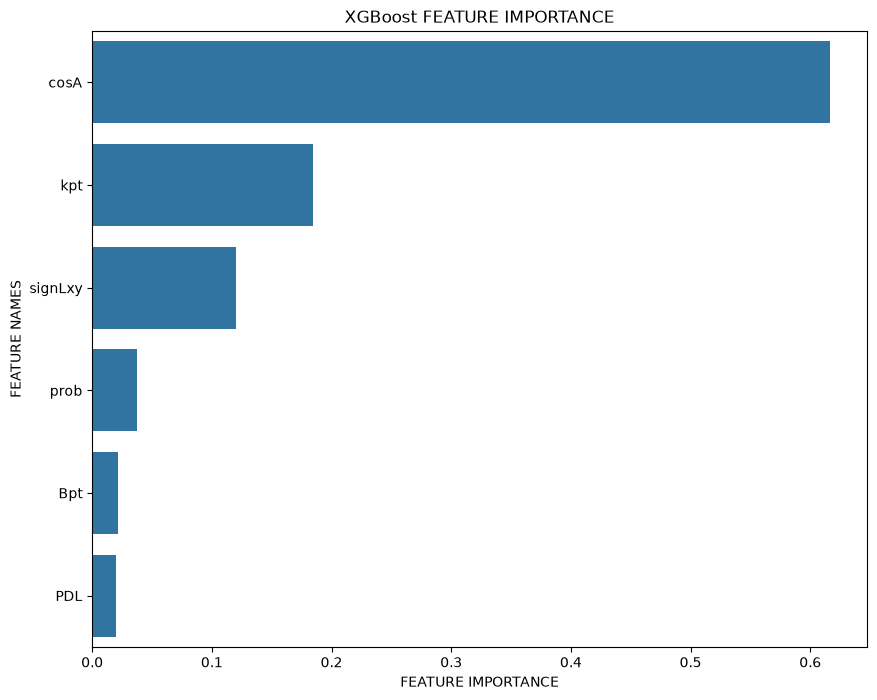

In [21]:
# Plotting feature importances.
ptf.plot_feature_importance(model_precision.feature_importances_, train[cols].columns, "XGBoost")

### Evaluation

Own ks test

	0.8560873777461462
	0.05659666627921


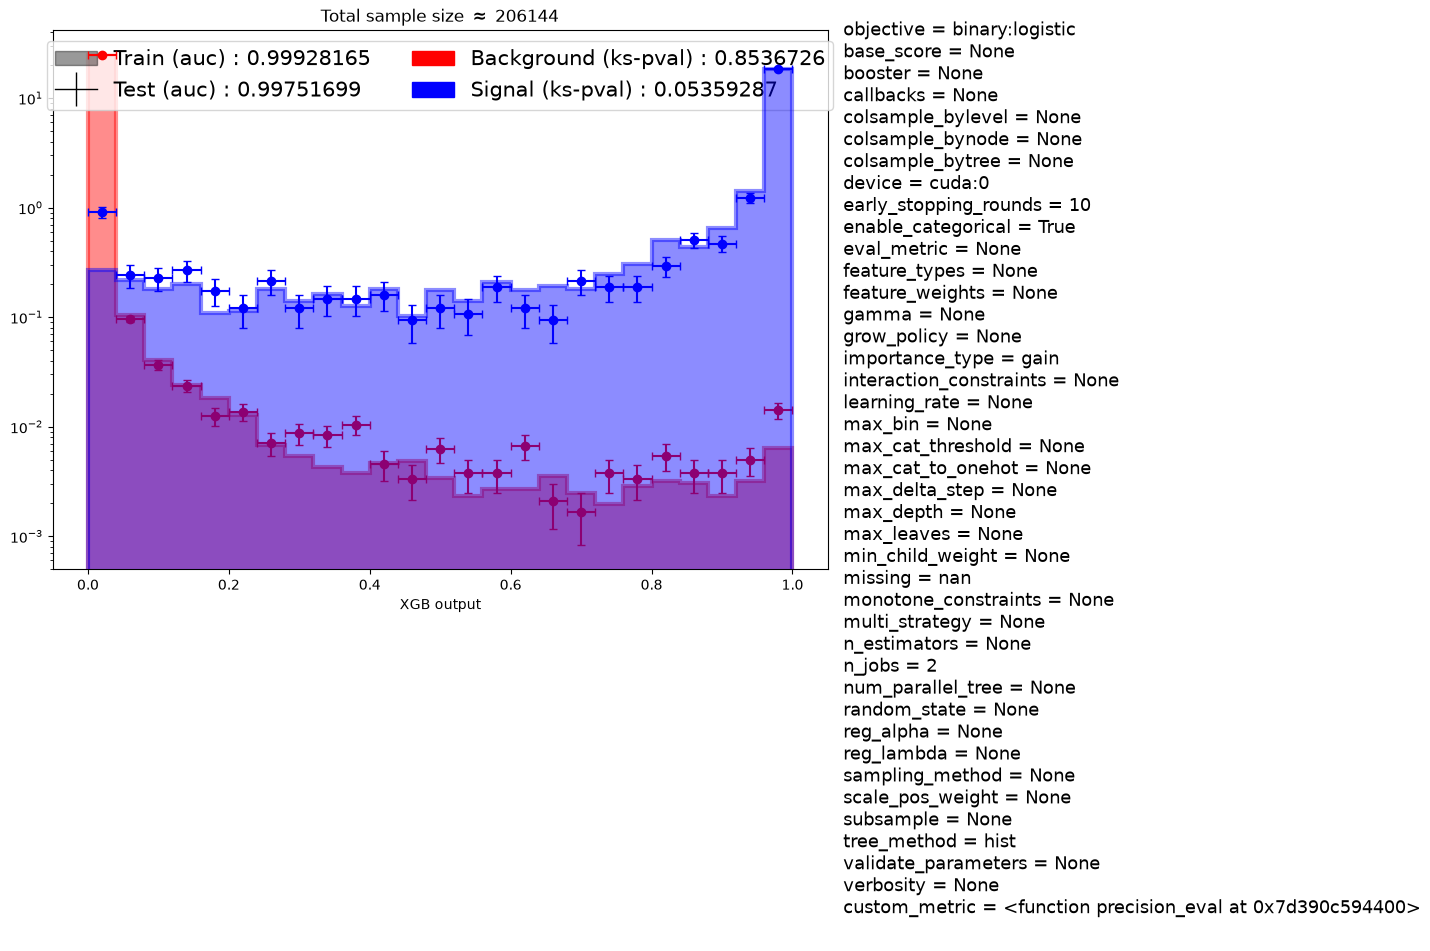

In [22]:
# Plotting classifier distributions
fig, ax = ptf.plot_classifier_distributions(model_precision, test=test, train=train, cols=cols, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()

Text(0.5, 1.0, 'precision-recall curve for precision model')

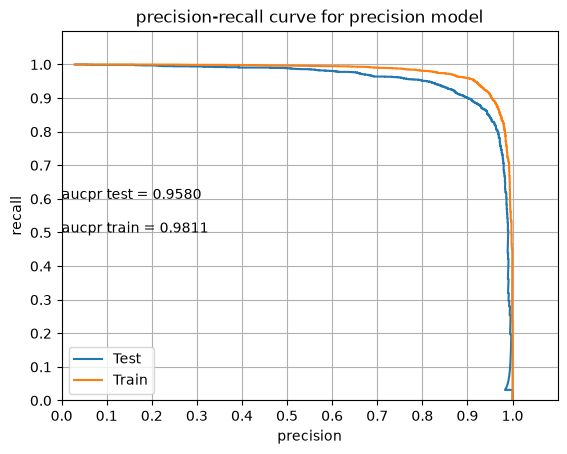

In [23]:
# Plotting the precision-recall curve for our model.
fig, ax = ptf.plot_precision_recall_curve(model_precision, train, test, cols)
plt.title('precision-recall curve for precision model')

In [24]:
model_precision.save_model(path_+"precision_model.json") #Saving our model into a destination and with a name of our choice

# **AUC metric**

### First XGB AUC **model**

In [25]:
# Creating an XGBoost model
model_auc = xgb.XGBClassifier(objective='binary:logistic',
                         tree_method = 'hist',
                         device="cuda:0",
                         n_jobs=os.cpu_count(),
                         importance_type = 'gain',
                         eval_metric='auc' #In this case, the metric is included in XGBoost, so we add it inside the XGB classifier definition
                      )

In [26]:
# Defining parameters for our model.
model_auc.set_params(early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, num_parallel_tree=None, ...)

In [27]:
# Training the model with our data using the recall metric
model_auc.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, num_parallel_tree=None, ...)

{'Bpt': 0.02151486650109291,
 'PDL': 0.019993692636489868,
 'cosA': 0.6139949560165405,
 'kpt': 0.1854386180639267,
 'prob': 0.037098538130521774,
 'signLxy': 0.12195927649736404}


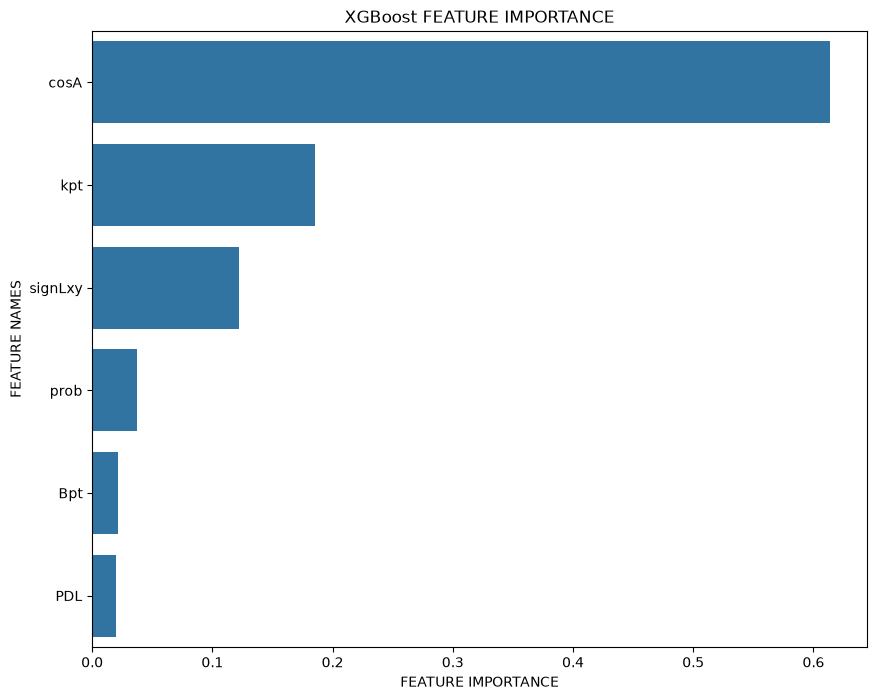

In [28]:
# Plotting feature importances.
ptf.plot_feature_importance(model_auc.feature_importances_, train[cols].columns, "XGBoost")

### Evaluation

Own ks test

	0.7193380735693549
	0.05230528103078357


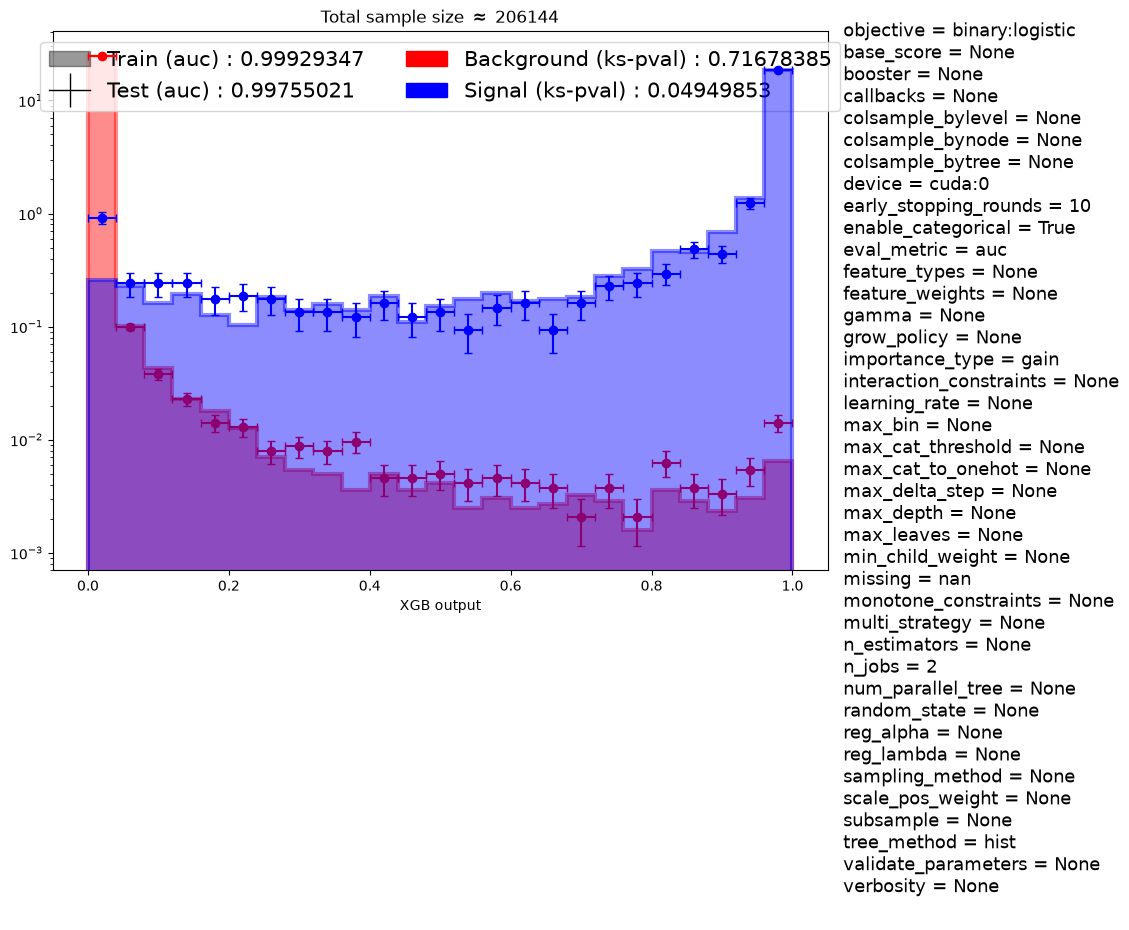

In [29]:
# Plotting classifier distributions
fig, ax = ptf.plot_classifier_distributions(model_auc, test=test, train=train, cols=cols, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()

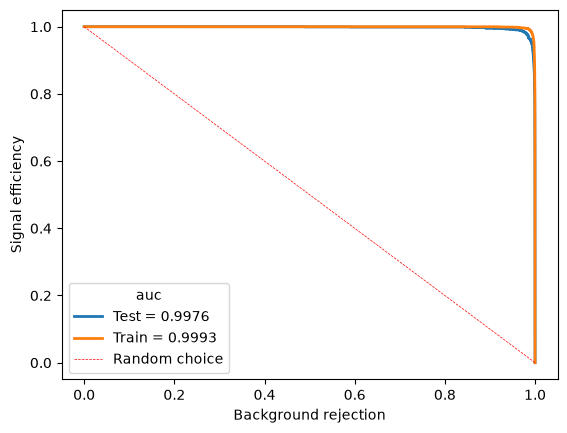

In [30]:
# Plotting the ROC curve to obtain the AUC.
ptf.plot_roc_curve(model_auc, test, train, cols)

In [31]:
model_auc.save_model(path_+"model_auc.json") #Saving our model into a destination and with a name of our choice

# **Hyperparameter search preliminars**

### Defining objective functions

In [32]:
# Defining the objective function using the XGBClassifier. We need this function in order to perform the hyperparameter search.
def objective_recall(space):
#Inside the function we define and fit an XGBoost classifier model just like we did before. Using the recall metric in this case.
    model=xgb.XGBClassifier(objective='binary:logistic',
                          tree_method = 'hist',
                          device="cuda:0",
                          n_jobs=os.cpu_count(),
                          importance_type = 'gain'
                          )

    evaluation = [(train[cols], train['label']),(test[cols],test['label'])]

    model.set_params(custom_metric = ptf.recall_eval, early_stopping_rounds=10)

    model.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)


    pred = model.predict(test[cols]) #Additionally we obtain the predicted probabilities from our model.
    rec = recall_score(test['label'], pred>0.5) #We calculate the recall score from the test DataFrame using the recall_score from sklearn.metrics
    print ("SCORE:", rec) #We print the result from the recall metric.
    return {'loss': -rec, 'status': STATUS_OK}

In [33]:
# Defining the objective function using the XGBClassifier.
def objective_precision(space):
#We define and fit an XGBoost classifier model.
    model=xgb.XGBClassifier(objective='binary:logistic',
                          tree_method = 'hist',
                          device="cuda:0",
                          n_jobs=os.cpu_count(),
                          importance_type = 'gain'
                          )

    model.set_params(custom_metric = ptf.precision_eval, early_stopping_rounds=10)

    model.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)


    pred = model.predict(test[cols]) #Additionally we obtain the predicted probabilities from our model.
    prec = precision_score(test['label'], pred>0.5) #We calculate the recall score from the test DataFrame using the recall_score from sklearn.metrics
    print ("SCORE:", prec) #We print the result from the precision metric.
    return {'loss': -prec, 'status': STATUS_OK}

In [34]:
# Defining the objective function using the XGBClassifier.
def objective_auc(space):
#We define and fit an XGBoost classifier model.
    model=xgb.XGBClassifier(objective='binary:logistic',
                          tree_method = 'hist',
                          device="cuda:0",
                          n_jobs=os.cpu_count(),
                          importance_type = 'gain',
                          eval_metric='auc'
                          )

    model.set_params(early_stopping_rounds=10)

    model.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)


    pred = model.predict(test[cols]) #Additionally we obtain the predicted probabilities from our model.
    auc = roc_auc_score(test['label'], pred>0.5) #We calculate the recall score from the test DataFrame using the recall_score from sklearn.metrics
    print ("SCORE:", auc) #We print the result from the auc metric.
    return {'loss': -auc, 'status': STATUS_OK}

### Defining hyperparameter spaces

There exist two kinds of hyperparameters, performance hyperparameters and regularization hyperparameters. We perform a hyperparameter search for each of them.

There are a few different ways to perform a hyperparameter search. In this case, we will use a method called bayesian optimization.

In [35]:
# Defining the hyperparameter space for performance hyperparameters

#We define the hyperparameter space. We will only perform the hyperaparameter search for this hyperparameters (max_leaves, max_depth)
# The possible values for the hyperparameters are given by the hyperopt hp function
max_leaves_s = np.arange(1, 100+1, dtype=int)
max_depth_s = np.arange(3, 10+1, dtype=int)

param_space_per = {
           'max_leaves': hp.choice('max_leaves', max_leaves_s),
           'max_depth': hp.choice('max_depth', max_depth_s),
           }

In [36]:
# Defining the hyperparameter space for regularization hyperparameters similarly.

reg_alpha_s= np.arange(0, 10, 1)
reg_lambda_s= np.arange(0, 10, 1)

param_space_reg = {
    'reg_alpha': hp.choice('reg_alpha', reg_alpha_s),
    'reg_lambda': hp.choice('reg_lambda', reg_lambda_s),
}

# **Hyperparameter search**

## Recall

### performance hyperparams

In [116]:
#Performing the hyperparameter search with the fmin function from the hyperopt library. Using the bayesian optimization method.
best_per_hyperparams = fmin(fn = objective_recall, #Specifiying the objective function to use
                        space = param_space_per, #Using the hyperparameter space previously defined.
                        algo = tpe.suggest, # Using the Tree-structured Parzen Estimator function from hyperopt as algorithm
                        max_evals = 100, # The maximum number of trials (or evaluations) the optimization algorithm will conduct
                        )

SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.884

In [117]:
print(best_per_hyperparams)

{'max_depth': np.int64(5), 'max_leaves': np.int64(4)}


In [118]:
# Creating an XGBoost model with the optimized hyperparameters
opt_model_recall = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain', # Dictates the metric to calculate feature importance
                         #Using the hyperparameter values obtained from the hyperparameter search
                         max_depth = best_per_hyperparams['max_depth'],
                         max_leaves = best_per_hyperparams['max_leaves']
                      )

# Adding the pertinent parameters just like before
opt_model_recall.set_params(custom_metric = ptf.recall_eval, early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function recall_eval at 0x7d390c594360>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(5), max_leaves=np.int64(4),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2, ...)

In [119]:
# Training the new optimized model
opt_model_recall.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function recall_eval at 0x7d390c594360>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(5), max_leaves=np.int64(4),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2, ...)

### Evaluation

Own ks test

	0.2878657435326997
	0.28927757660196707


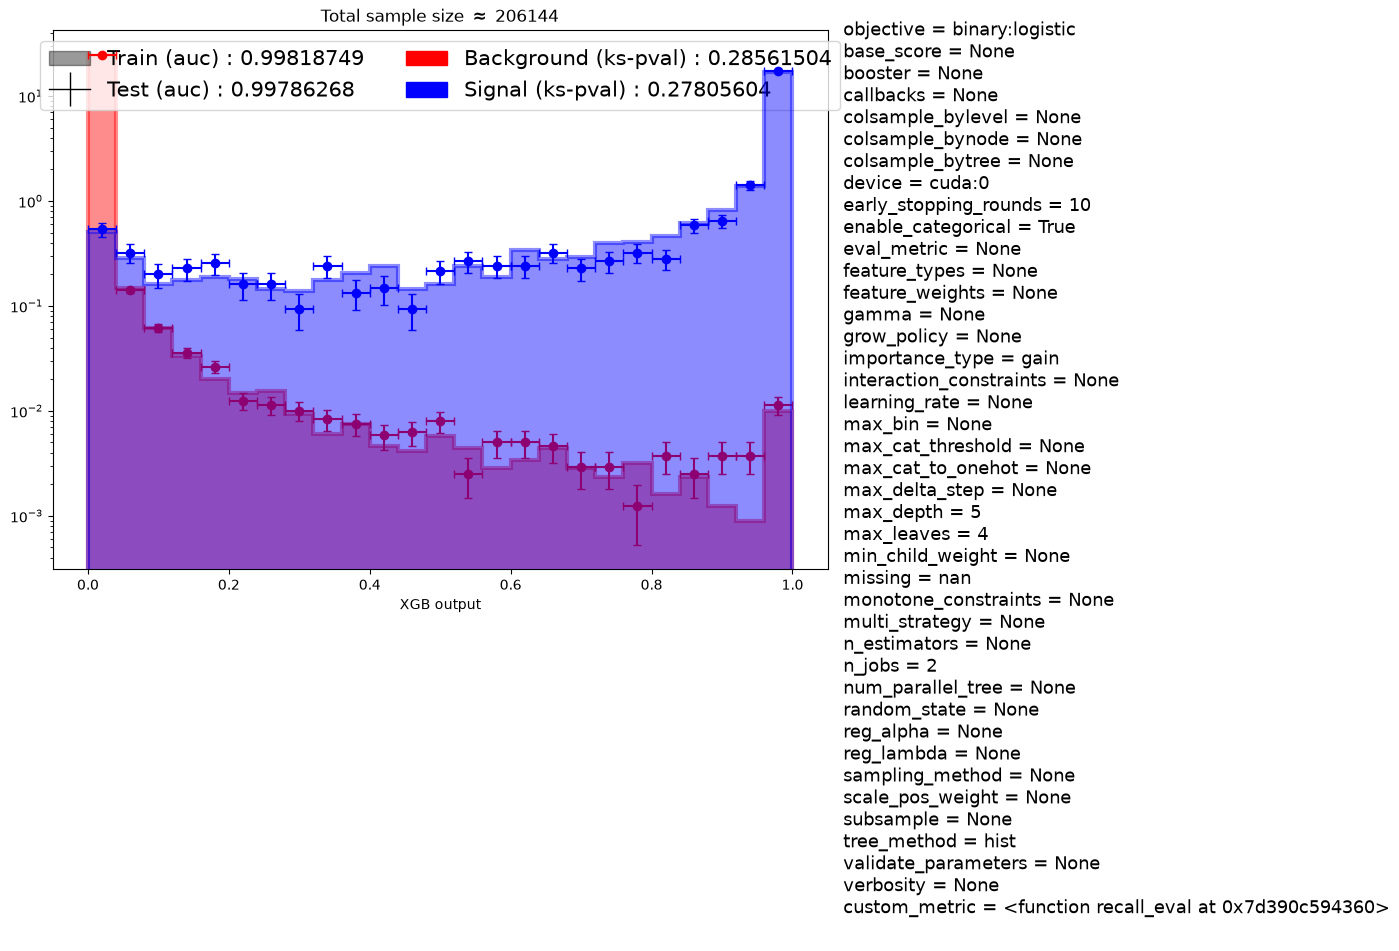

In [120]:
# Poltting the classifier distributions
fig, ax = ptf.plot_classifier_distributions(opt_model_recall, test=test, train=train, cols=cols, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()
#We can see from these results that the pval from the signal DataFrame enhanced but sacrificing the pval from the background. However, now both account as acceptable pvals.

Text(0.5, 1.0, 'precision-recall curve for optimized recall model')

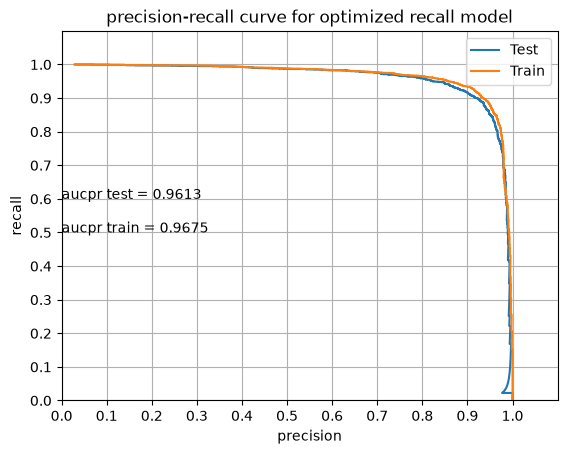

In [121]:
# Plotting the precision-recall curve and obtaining the aucpr results
fig, ax = ptf.plot_precision_recall_curve(opt_model_recall, train, test, cols)
plt.title('precision-recall curve for optimized recall model')
# The acupr test value enhanced and there is still no overtraining.

In [122]:
opt_model_recall.save_model(path_+"optimized_recall_model_per_hparams.json") #Saving our model into a destination and with a name of our choice

### regularization hyperparams

In [104]:
#Performing the hyperparameter search.
best_reg_hyperparams = fmin(fn = objective_recall, #Specifiying the objective function to use
                        space = param_space_reg, #Using the hyperparameter space previously defined.
                        algo = tpe.suggest, # Using the Tree-structured Parzen Estimator function from hyperopt as algorithm
                        max_evals = 100, # The maximum number of trials (or evaluations) the optimization algorithm will conduct
                        )

SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.884

In [105]:
print(best_reg_hyperparams)

{'reg_alpha': np.int64(7), 'reg_lambda': np.int64(5)}


In [106]:
# Creating an XGBoost model with the optimized hyperparameters
opt_model_recall = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain', # Dictates the metric to calculate feature importance
                         #Using the hyperparameter values obtained from the hyperparameter search
                         reg_alpha = best_reg_hyperparams['reg_alpha'],
                         reg_lambda = best_reg_hyperparams['reg_lambda']
                      )

# Adding the pertinent parameters just like before
opt_model_recall.set_params(custom_metric = ptf.recall_eval, early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function recall_eval at 0x7d390c594360>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, ...)

In [107]:
# Training the new optimized model
opt_model_recall.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function recall_eval at 0x7d390c594360>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, ...)

### Evaluation

Own ks test

	0.8539551454162013
	0.4548782246270176


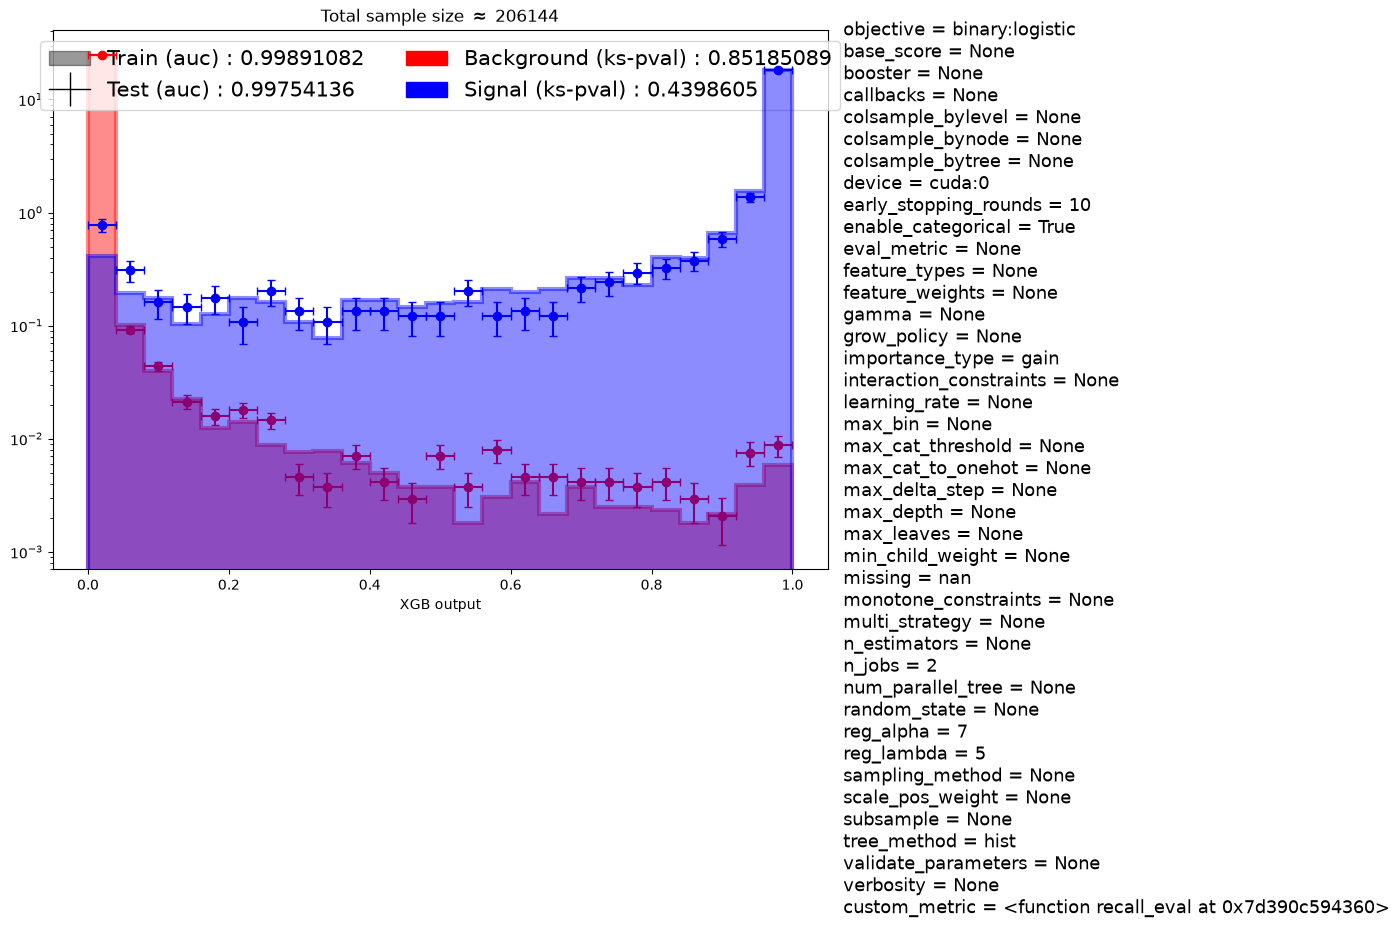

In [108]:
# Poltting the classifier distributions
fig, ax = ptf.plot_classifier_distributions(opt_model_recall, test=test, train=train, cols=cols, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()
#This model enhanced the signal pval and left practically the same value for background.

Text(0.5, 1.0, 'precision-recall curve for optimized recall model')

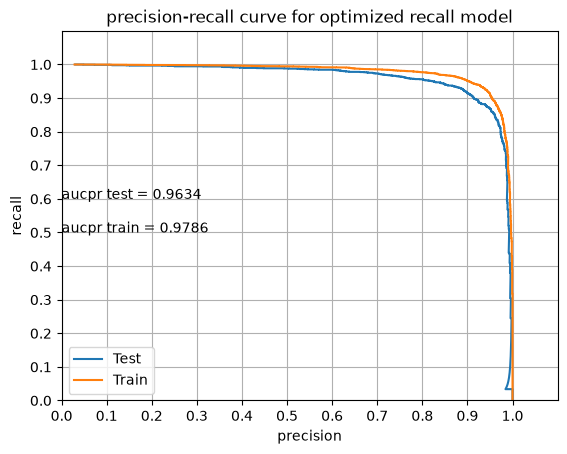

In [109]:
# Plotting the precision-recall curve and obtaining the aucpr results
fig, ax = ptf.plot_precision_recall_curve(opt_model_recall, train, test, cols)
plt.title('precision-recall curve for optimized recall model')
#This model enhanced again the aucpr test without overtraining.

In [110]:
opt_model_recall.save_model(path_+"optimized_recall_model_reg_hparams.json") #Saving our model into a destination and with a name of our choice

### mixed hyperparams


In [123]:
# Creating an XGBoost model with the optimized hyperparameters
opt_model_recall = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain', # Dictates the metric to calculate feature importance
                         #Using the hyperparameter values obtained from the hyperparameter search
                         max_depth = best_per_hyperparams['max_depth'],
                         max_leaves = best_per_hyperparams['max_leaves'],
                         reg_alpha = best_reg_hyperparams['reg_alpha'],
                         reg_lambda = best_reg_hyperparams['reg_lambda']
                      )

# Adding the pertinent parameters just like before
opt_model_recall.set_params(custom_metric = ptf.recall_eval, early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function recall_eval at 0x7d390c594360>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(5), max_leaves=np.int64(4),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2, ...)

In [124]:
# Training the new optimized model
opt_model_recall.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function recall_eval at 0x7d390c594360>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(5), max_leaves=np.int64(4),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2, ...)

### Evaluation

Own ks test

	0.4642786222516298
	0.3131233596905486


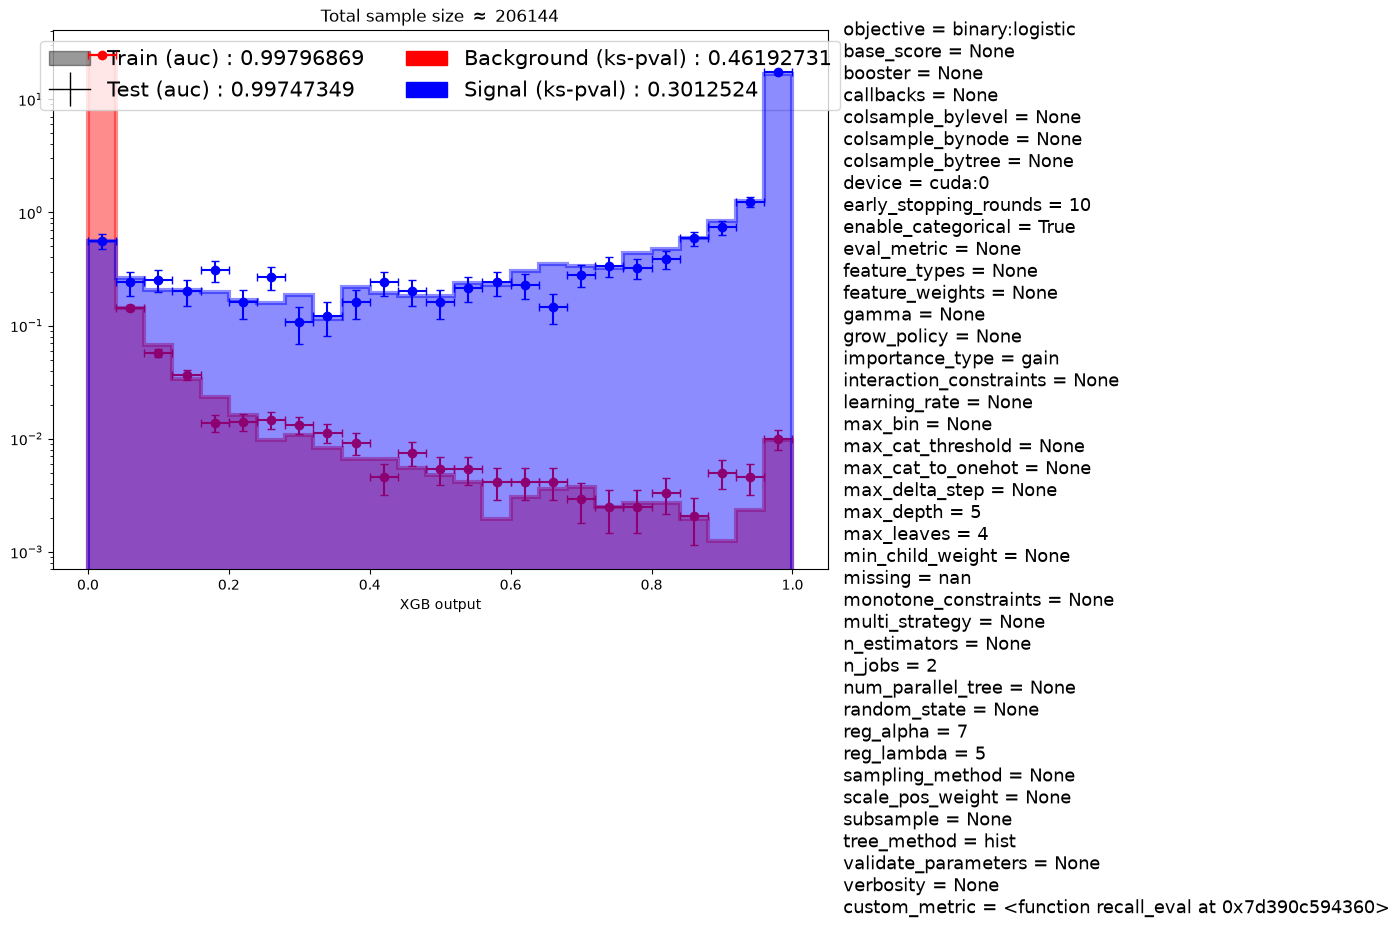

In [125]:
# Poltting the classifier distributions
fig, ax = ptf.plot_classifier_distributions(opt_model_recall, test=test, train=train, cols=cols, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()
# Mixing both models resulted in acceptable pvals for both signal and background.

Text(0.5, 1.0, 'precision-recall curve for optimized recall model')

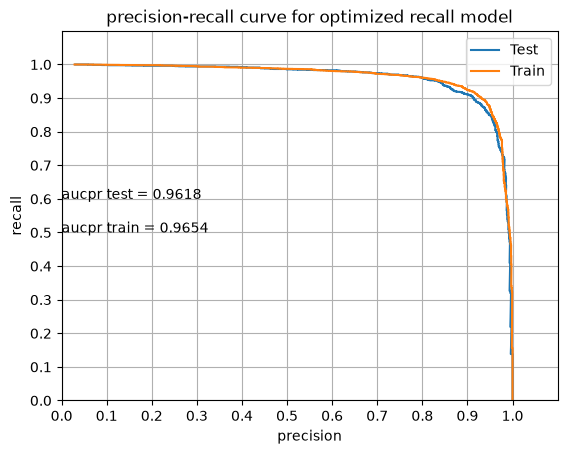

In [126]:
# Plotting the precision-recall curve and obtaining the aucpr results
fig, ax = ptf.plot_precision_recall_curve(opt_model_recall, train, test, cols)
plt.title('precision-recall curve for optimized recall model')
# Not the best aucpr value, but still better than the initial one and without overtraining.

In [55]:
opt_model_recall.save_model(path_+"optimized_recall_model_mixed_hparams.json") #Saving our model into a destination and with a name of our choice

## Precision

### performance hyperparams

In [56]:
#Performing the hyperparameter search with the fmin function from the hyperopt library. Using the bayesian optimization method.
best_per_hyperparams = fmin(fn = objective_precision, #Specifiying the objective function to use
                        space = param_space_per, #Using the hyperparameter space previously defined.
                        algo = tpe.suggest, # Using the Tree-structured Parzen Estimator function from hyperopt as algorithm
                        max_evals = 100, # The maximum number of trials (or evaluations) the optimization algorithm will conduct
                        )

SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.919

In [57]:
print(best_per_hyperparams)

{'max_depth': np.int64(2), 'max_leaves': np.int64(95)}


In [58]:
# Creating an XGBoost model with the optimized hyperparameters
opt_model_precision = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain', # Dictates the metric to calculate feature importance
                         #Using the hyperparameter values obtained from the hyperparameter search
                         max_depth = best_per_hyperparams['max_depth'],
                         max_leaves = best_per_hyperparams['max_leaves']
                      )

# Adding the pertinent parameters just like before
opt_model_precision.set_params(custom_metric = ptf.precision_eval, early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function precision_eval at 0x7d390c594400>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(2), max_leaves=np.int64(95),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2, ...)

In [59]:
# Training the new optimized model
opt_model_precision.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function precision_eval at 0x7d390c594400>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(2), max_leaves=np.int64(95),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2, ...)

### Evaluation

Own ks test

	0.2729152924493648
	0.24980811168256237


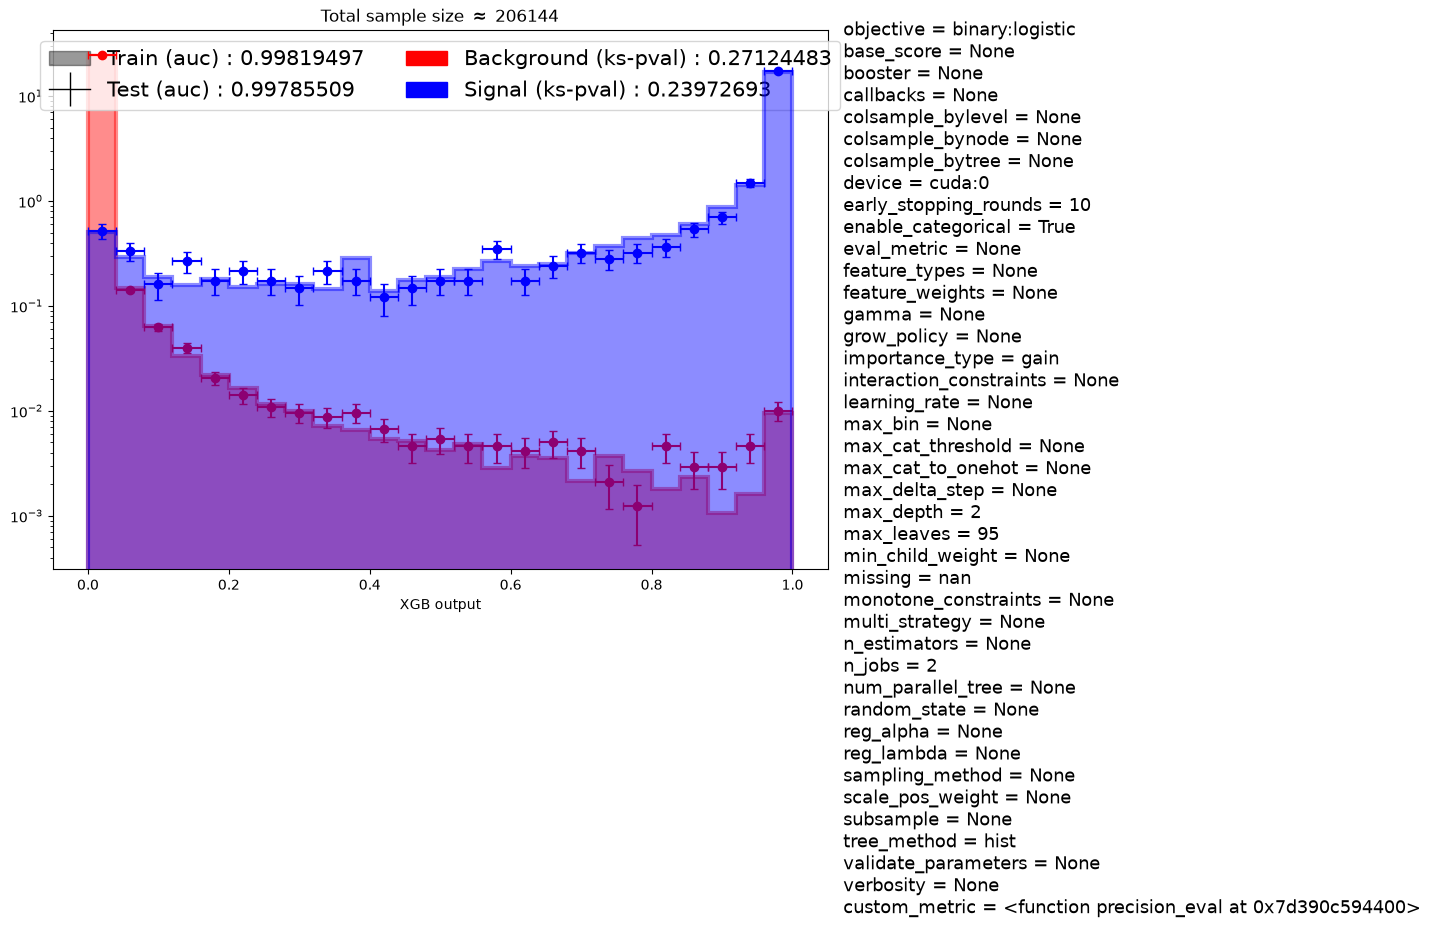

In [60]:
# Poltting the classifier distributions
fig, ax = ptf.plot_classifier_distributions(opt_model_precision, test=test, train=train, cols=cols, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()
# Enhanced the signal pval sacrificing the background pval.

Text(0.5, 1.0, 'precision-recall curve for optimized precision model')

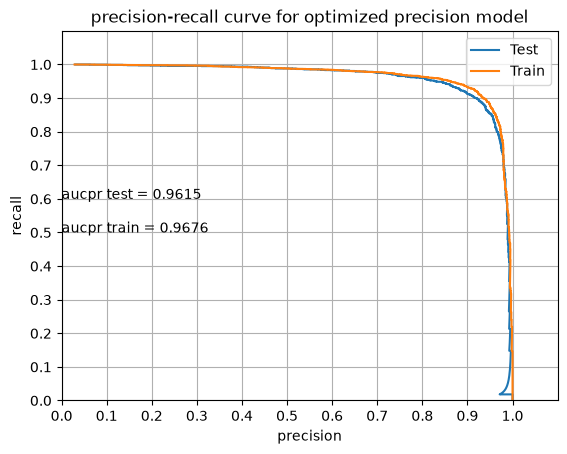

In [61]:
# Plotting the precision-recall curve and obtaining the aucpr results
fig, ax = ptf.plot_precision_recall_curve(opt_model_precision, train, test, cols)
plt.title('precision-recall curve for optimized precision model')
# Better aucpr test result without overtraining.

In [62]:
opt_model_precision.save_model(path_+"optimized_precision_model_per_hparams.json") #Saving our model into a destination and with a name of our choice

### regularization hyperparams

In [63]:
#Performing the hyperparameter search.
best_reg_hyperparams = fmin(fn = objective_precision, #Specifiying the objective function to use
                        space = param_space_reg, #Using the hyperparameter space previously defined.
                        algo = tpe.suggest, # Using the Tree-structured Parzen Estimator function from hyperopt as algorithm
                        max_evals = 100, # The maximum number of trials (or evaluations) the optimization algorithm will conduct
                        )

SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.919

In [64]:
print(best_reg_hyperparams)

{'reg_alpha': np.int64(0), 'reg_lambda': np.int64(8)}


In [65]:
# Creating an XGBoost model with the optimized hyperparameters
opt_model_precision = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain', # Dictates the metric to calculate feature importance
                         #Using the hyperparameter values obtained from the hyperparameter search
                         reg_alpha = best_reg_hyperparams['reg_alpha'],
                         reg_lambda = best_reg_hyperparams['reg_lambda']
                      )

# Adding the pertinent parameters just like before
opt_model_precision.set_params(custom_metric = ptf.precision_eval, early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function precision_eval at 0x7d390c594400>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, ...)

In [66]:
# Training the new optimized model
opt_model_precision.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function precision_eval at 0x7d390c594400>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, ...)

### Evaluation

Own ks test

	0.4090776858435131
	0.13971919548183212


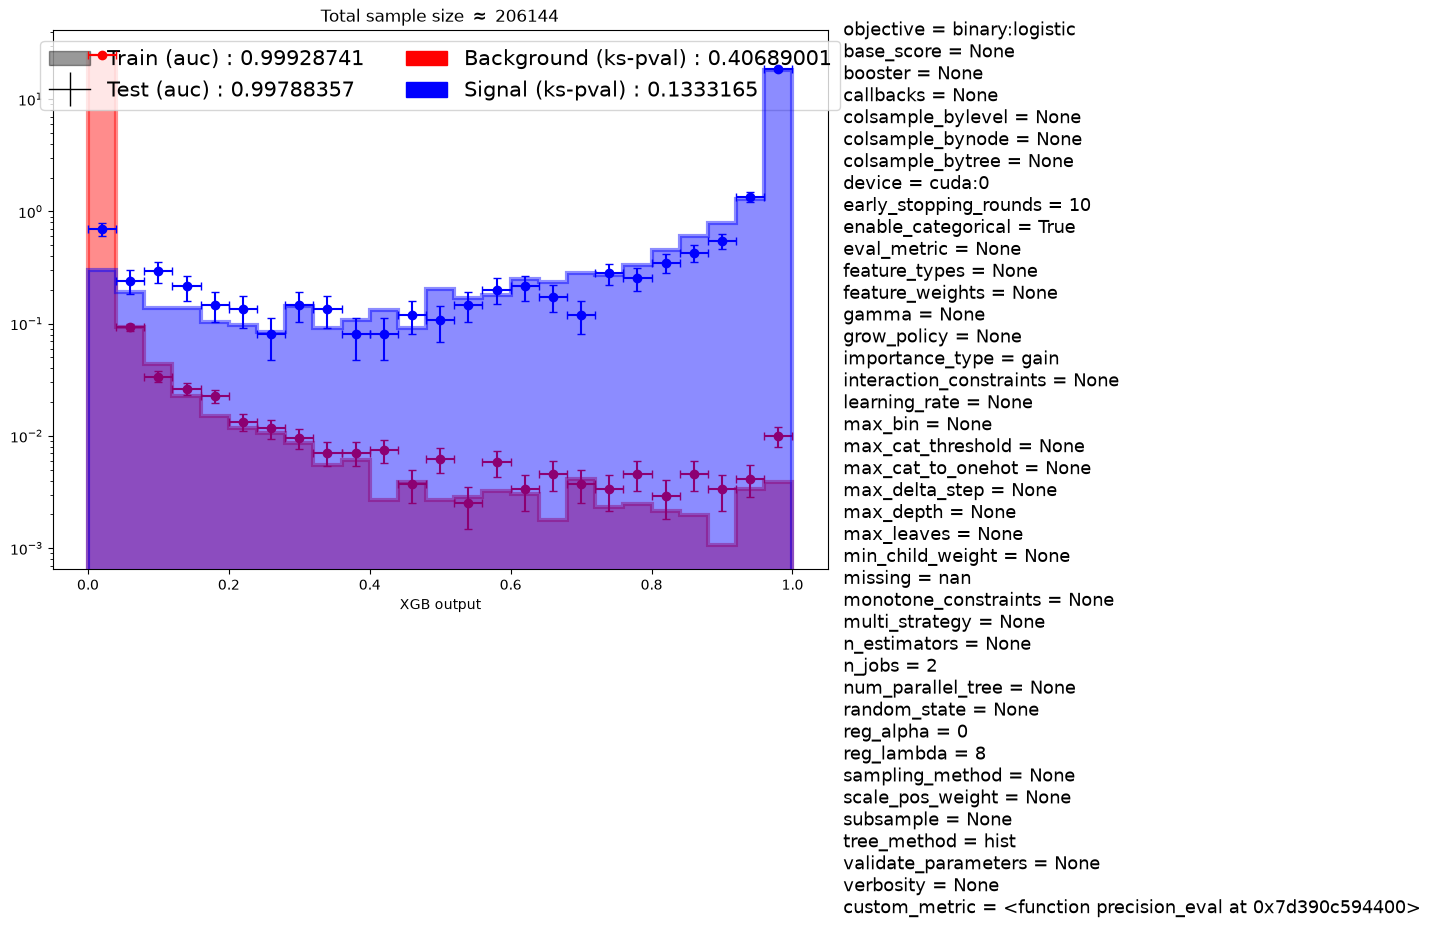

In [67]:
# Poltting the classifier distributions
fig, ax = ptf.plot_classifier_distributions(opt_model_precision, test=test, train=train, cols=cols, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()
# Still enhanced the pval for signal, although not as much as the performance model.

Text(0.5, 1.0, 'precision-recall curve for optimized precision model')

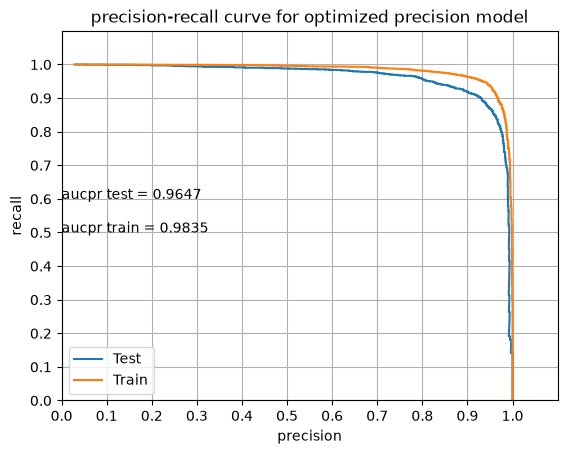

In [68]:
# Plotting the precision-recall curve and obtaining the aucpr results
fig, ax = ptf.plot_precision_recall_curve(opt_model_precision, train, test, cols)
plt.title('precision-recall curve for optimized precision model')
# The aucpr test result was even better.

In [69]:
opt_model_precision.save_model(path_+"optimized_precision_model_reg_hparams.json") #Saving our model into a destination and with a name of our choice

### mixed hyperparameters

In [70]:
# Creating an XGBoost model with the optimized hyperparameters
opt_model_precision = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain', # Dictates the metric to calculate feature importance
                         #Using the hyperparameter values obtained from the hyperparameter search
                         max_depth = best_per_hyperparams['max_depth'],
                         max_leaves = best_per_hyperparams['max_leaves'],
                         reg_alpha = best_reg_hyperparams['reg_alpha'],
                         reg_lambda = best_reg_hyperparams['reg_lambda']
                      )

# Adding the pertinent parameters just like before
opt_model_precision.set_params(custom_metric = ptf.precision_eval, early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function precision_eval at 0x7d390c594400>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(2), max_leaves=np.int64(95),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2, ...)

In [71]:
# Training the new optimized model
opt_model_precision.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function precision_eval at 0x7d390c594400>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(2), max_leaves=np.int64(95),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2, ...)

### Evaluation

Own ks test

	0.2150695888256661
	0.37507821968634303


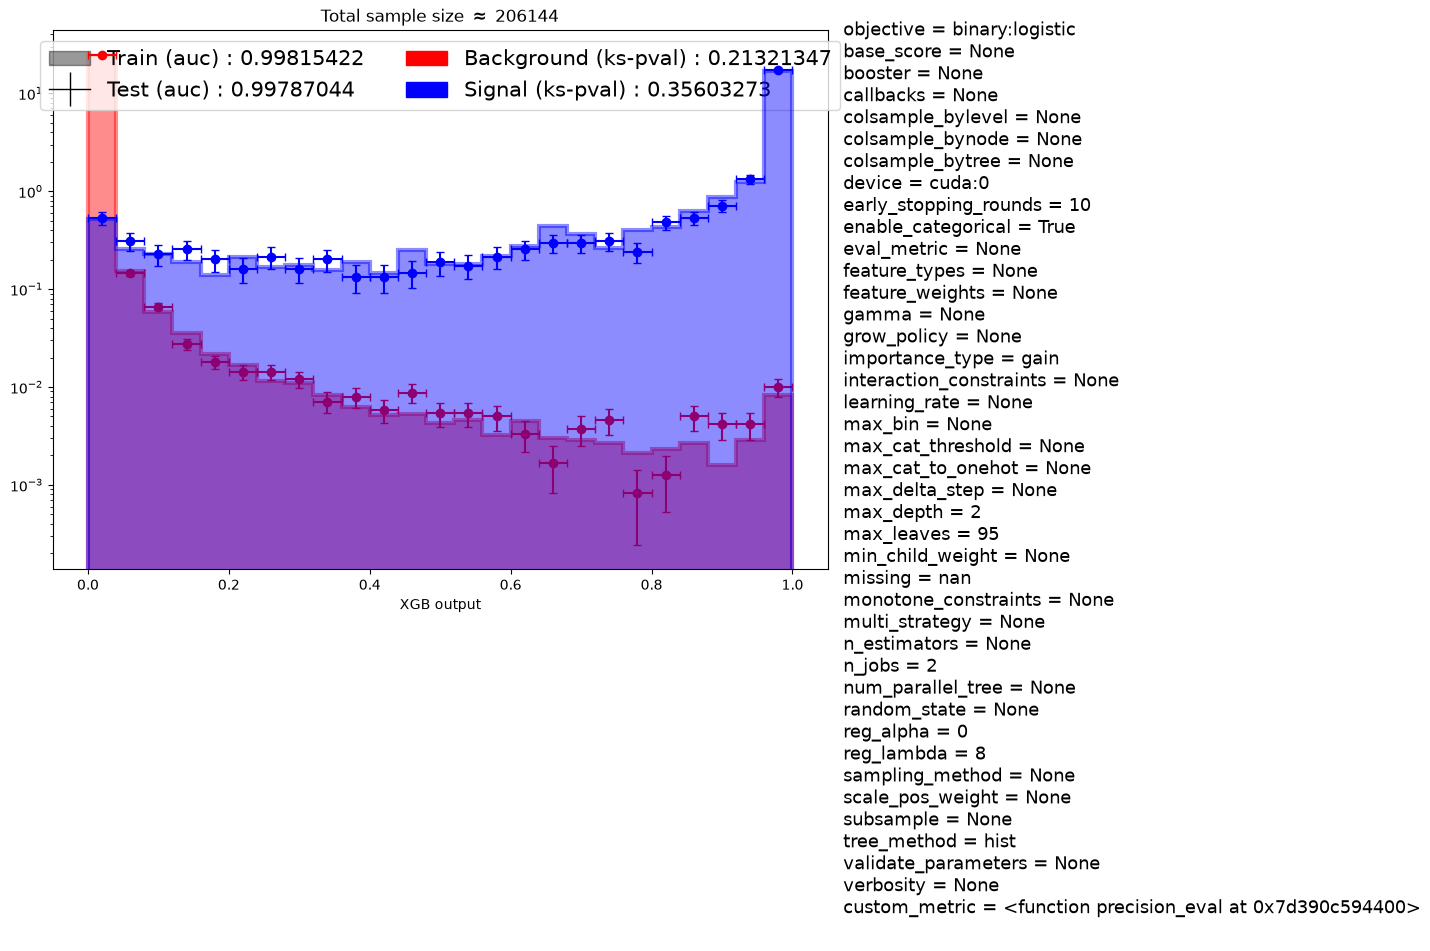

In [74]:
# Poltting the classifier distributions
fig, ax = ptf.plot_classifier_distributions(opt_model_precision, test=test, train=train, cols=cols, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()
# Acceptable pval results for both signal and background.

Text(0.5, 1.0, 'precision-recall curve for optimized precision model')

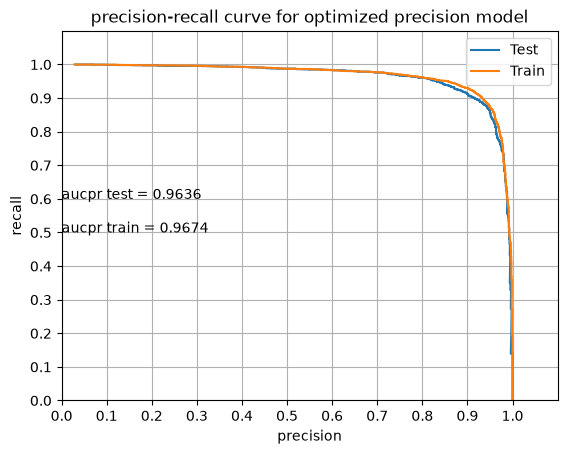

In [75]:
# Plotting the precision-recall curve and obtaining the aucpr results
fig, ax = ptf.plot_precision_recall_curve(opt_model_precision, train, test, cols)
plt.title('precision-recall curve for optimized precision model')
# Better aucpr result than the initial one.

In [76]:
opt_model_precision.save_model(path_+"optimized_precision_model_mixed_hparams.json") #Saving our model into a destination and with a name of our choice

## AUC

### performance hyperparams

In [77]:
#Performing the hyperparameter search with the fmin function from the hyperopt library. Using the bayesian optimization method.
best_per_hyperparams = fmin(fn = objective_auc, #Specifiying the objective function to use
                        space = param_space_per, #Using the hyperparameter space previously defined.
                        algo = tpe.suggest, # Using the Tree-structured Parzen Estimator function from hyperopt as algorithm
                        max_evals = 100, # The maximum number of trials (or evaluations) the optimization algorithm will conduct
                        )

SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765


In [78]:
print(best_per_hyperparams)

{'max_depth': np.int64(6), 'max_leaves': np.int64(35)}


In [79]:
# Creating an XGBoost model with the optimized hyperparameters
opt_model_auc = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain', # Dictates the metric to calculate feature importance,
                         eval_metric= 'auc',
                         #Using the hyperparameter values obtained from the hyperparameter search
                         max_depth = best_per_hyperparams['max_depth'],
                         max_leaves = best_per_hyperparams['max_leaves']
                      )

# Adding the pertinent parameters just like before
opt_model_auc.set_params(early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(6), max_leaves=np.int64(35),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2,
              num_parallel_tree=None, ...)

In [80]:
# Training the new optimized model
opt_model_auc.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(6), max_leaves=np.int64(35),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2,
              num_parallel_tree=None, ...)

### Evaluation

Own ks test

	0.722584116034607
	0.010537726138584984


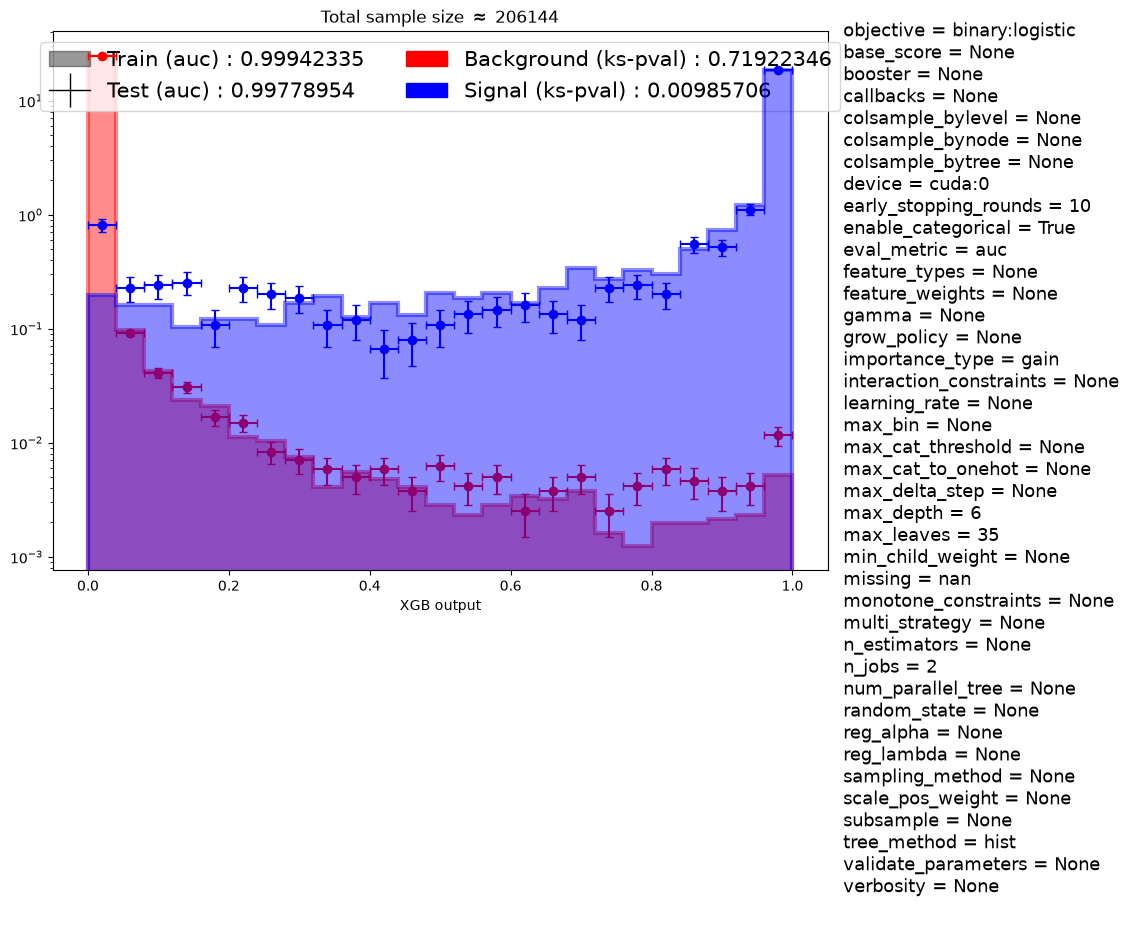

In [81]:
# Plotting classifier distributions
fig, ax = ptf.plot_classifier_distributions(opt_model_auc, test=test, train=train, cols=cols, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()
# Performance hyperparams did not help for the signal pval, hopefully mixing both hyperparams fixes this.

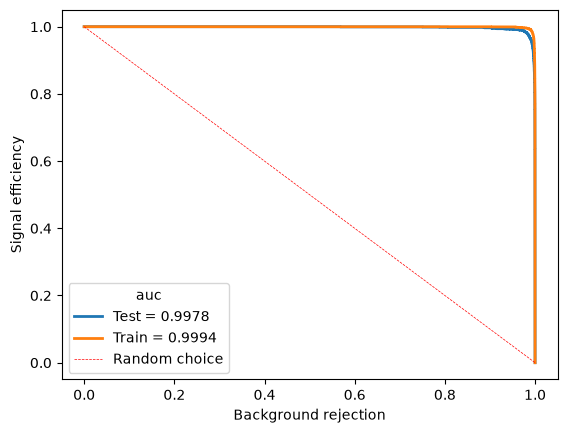

In [82]:
# Plotting the ROC curve to obtain the AUC.
ptf.plot_roc_curve(opt_model_auc, test, train, cols)
# The AUC result enhanced for this model.

In [83]:
opt_model_precision.save_model(path_+"optimized_auc_model_per_hparams.json") #Saving our model into a destination and with a name of our choice

### regularization hyperparams

In [84]:
#Performing the hyperparameter search.
best_reg_hyperparams = fmin(fn = objective_auc, #Specifiying the objective function to use
                        space = param_space_reg, #Using the hyperparameter space previously defined.
                        algo = tpe.suggest, # Using the Tree-structured Parzen Estimator function from hyperopt as algorithm
                        max_evals = 100, # The maximum number of trials (or evaluations) the optimization algorithm will conduct
                        )

SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765


In [85]:
print(best_reg_hyperparams)

{'reg_alpha': np.int64(3), 'reg_lambda': np.int64(2)}


In [86]:
# Creating an XGBoost model with the optimized hyperparameters
opt_model_auc = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain', # Dictates the metric to calculate feature importance,
                         eval_metric= 'auc',
                         #Using the hyperparameter values obtained from the hyperparameter search
                         reg_alpha = best_reg_hyperparams['reg_alpha'],
                         reg_lambda = best_reg_hyperparams['reg_lambda']
                      )

# Adding the pertinent parameters just like before
opt_model_auc.set_params(early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, num_parallel_tree=None, ...)

In [87]:
# Training the new optimized model
opt_model_auc.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, num_parallel_tree=None, ...)

### Evaluation

Own ks test

	0.4556393870629882
	0.2679076468543908


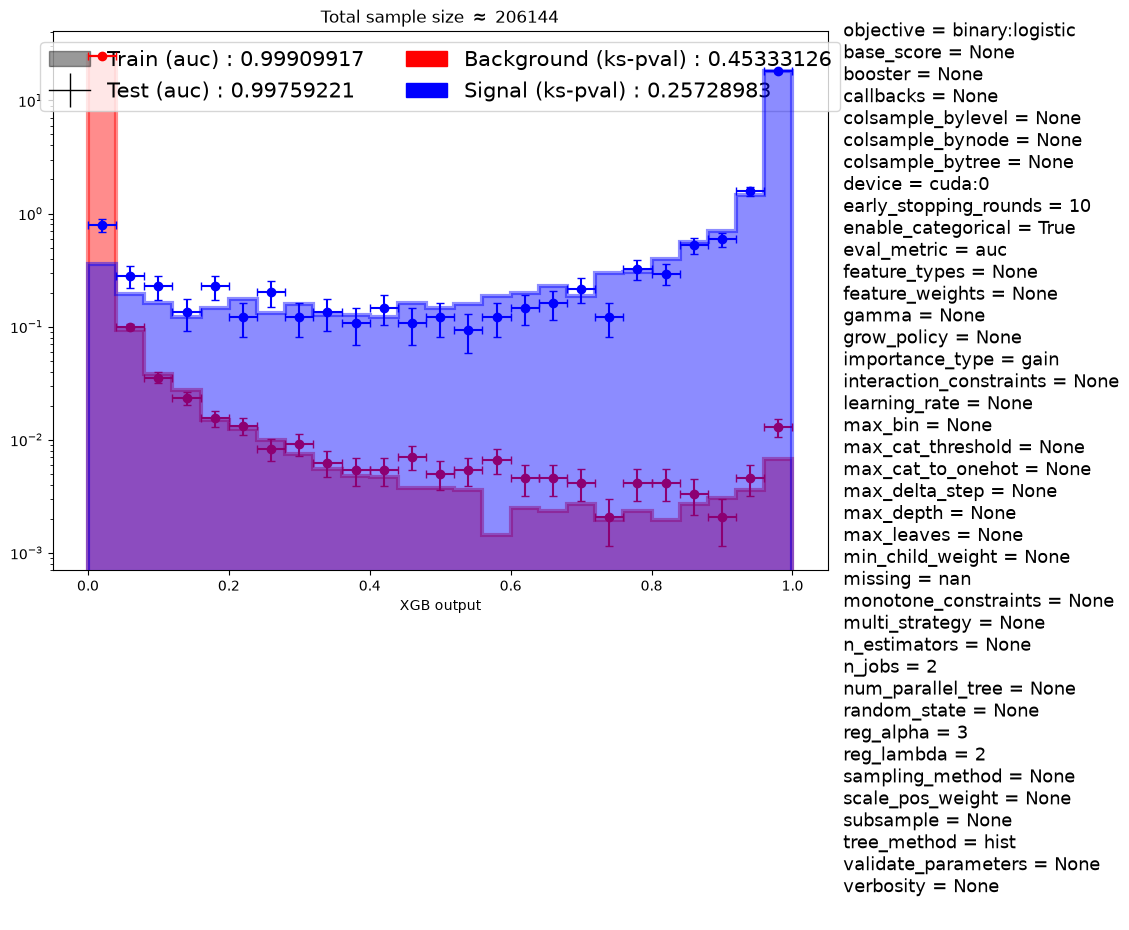

In [88]:
# Plotting classifier distributions
fig, ax = ptf.plot_classifier_distributions(opt_model_auc, test=test, train=train, cols=cols, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()
# The signal pval enhanced sacrificing the background pval.

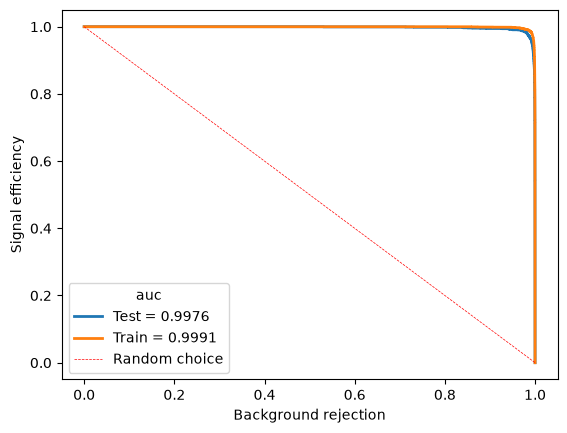

In [89]:
# Plotting the ROC curve to obtain the AUC.
ptf.plot_roc_curve(opt_model_auc, test, train, cols)
# The AUC result stayed practically the same (although it actually slightly increased)

In [90]:
opt_model_precision.save_model(path_+"optimized_auc_model_reg_hparams.json") #Saving our model into a destination and with a name of our choice

### mixed hyperparameters

In [91]:
# Creating an XGBoost model with the optimized hyperparameters
opt_model_auc = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain', # Dictates the metric to calculate feature importance
                         eval_metric = 'auc',
                         #Using the hyperparameter values obtained from the hyperparameter search
                         max_depth = best_per_hyperparams['max_depth'],
                         max_leaves = best_per_hyperparams['max_leaves'],
                         reg_alpha = best_reg_hyperparams['reg_alpha'],
                         reg_lambda = best_reg_hyperparams['reg_lambda']
                      )

# Adding the pertinent parameters just like before
opt_model_auc.set_params(early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(6), max_leaves=np.int64(35),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2,
              num_parallel_tree=None, ...)

In [92]:
# Training the new optimized model
opt_model_auc.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(6), max_leaves=np.int64(35),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2,
              num_parallel_tree=None, ...)

### Evaluation

Own ks test

	0.9665154764586461
	0.17799369707682


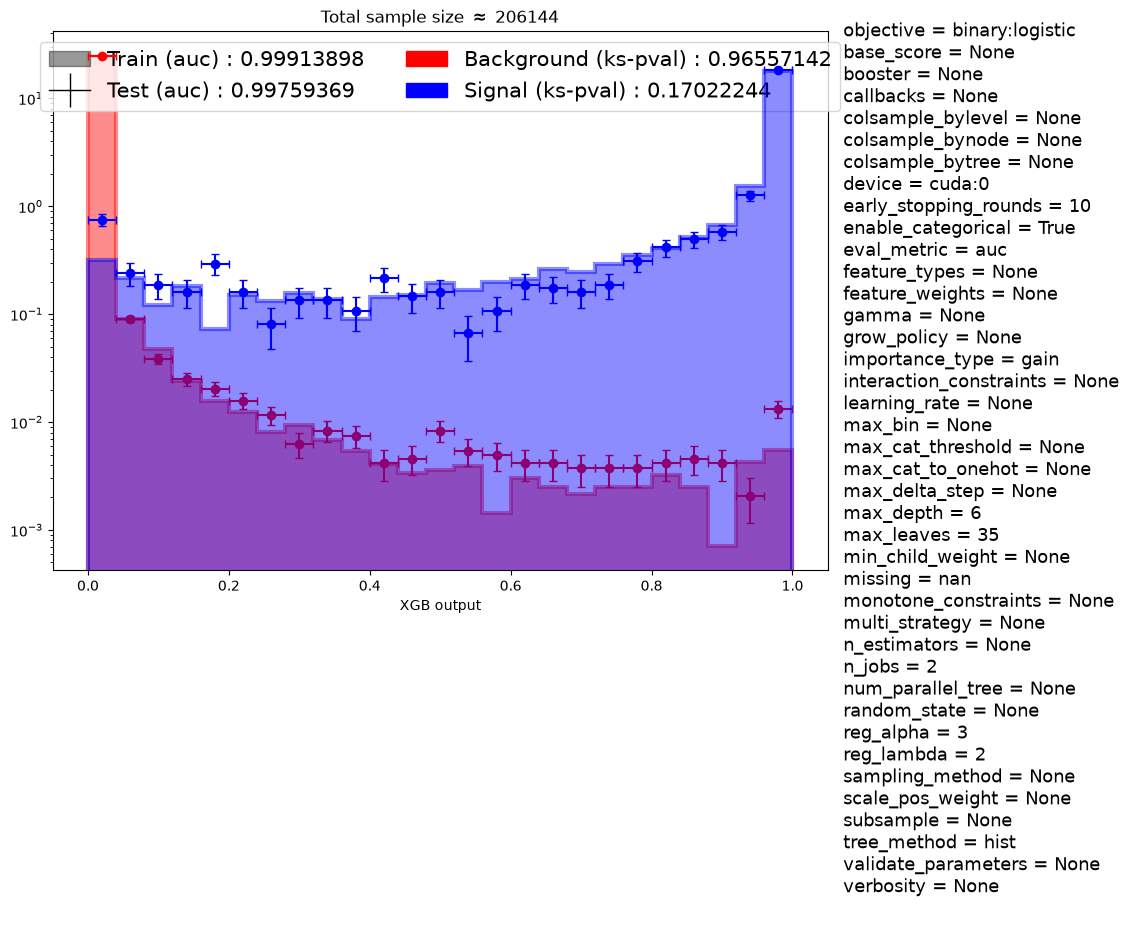

In [93]:
# Plotting classifier distributions
fig, ax = ptf.plot_classifier_distributions(opt_model_auc, test=test, train=train, cols=cols, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()
# Both signal and background pvals have acceptable values.

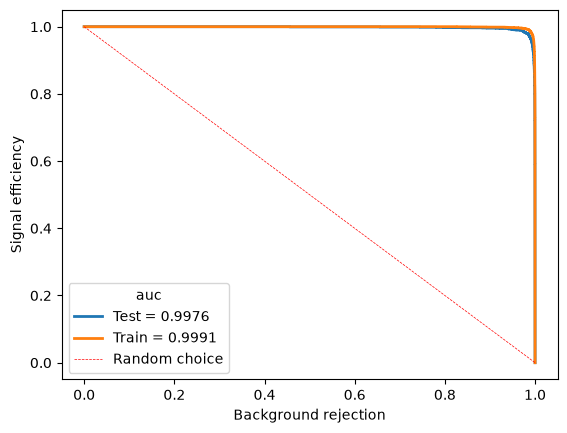

In [94]:
# Plotting the ROC curve to obtain the AUC.
ptf.plot_roc_curve(opt_model_auc, test, train, cols)
# Again the AUC result stayed practically the same as the initial one (but actually slightly increased).

In [95]:
opt_model_precision.save_model(path_+"optimized_auc_model_mixed_hparams.json") #Saving our model into a destination and with a name of our choice